In [18]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [19]:
import requests
import io

In [20]:
result=pd.read_csv('election_results_2024.csv')

In [21]:
result.head()

,State,Constituency,Candidate,Party,Votes,Position,Margin
0,Maharashtra,Constituency 1,Rajesh Kumar,INC,70232,1,9736
1,Maharashtra,Constituency 1,Kavita Joshi,BJP,60496,2,9736
2,Karnataka,Constituency 2,Amit Verma,BJP,63597,1,10219
3,Karnataka,Constituency 2,Rajesh Kumar,TMC,53378,2,10219
4,Rajasthan,Constituency 3,Arjun Das,SP,124624,1,70010


In [22]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   State         100 non-null    object
 1   Constituency  100 non-null    object
 2   Candidate     100 non-null    object
 3   Party         100 non-null    object
 4   Votes         100 non-null    int64 
 5   Position      100 non-null    int64 
 6   Margin        100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [23]:
result['Party'].value_counts()

Party
BJP          23
SP           18
Shiv Sena    17
INC          14
JDU          10
TMC           9
DMK           9
Name: count, dtype: int64

In [24]:
result['Party'].nunique()

7

In [25]:
winners= result[result['Position']==1]

In [27]:
seats_per_party= winners['Party'].value_counts()

seats_per_party

Party
BJP          15
SP            9
INC           7
JDU           7
Shiv Sena     5
DMK           4
TMC           3
Name: count, dtype: int64

In [29]:
top_margins = winners.sort_values(by='Margin', ascending=False).head(10)

top_margins

,State,Constituency,Candidate,Party,Votes,Position,Margin
80,Uttar Pradesh,Constituency 41,Arjun Das,SP,136234,1,95702
6,Rajasthan,Constituency 4,Priya Sharma,JDU,144906,1,95550
46,West Bengal,Constituency 24,Anita Singh,BJP,138399,1,85169
84,Bihar,Constituency 43,Arjun Das,INC,126246,1,83359
70,Tamil Nadu,Constituency 36,Sunita Devi,SP,122006,1,80542
4,Rajasthan,Constituency 3,Arjun Das,SP,124624,1,70010
8,Tamil Nadu,Constituency 5,Sunita Devi,SP,110569,1,69523
64,Rajasthan,Constituency 33,Kavita Joshi,Shiv Sena,132172,1,64378
42,Madhya Pradesh,Constituency 22,Anita Singh,BJP,105456,1,56494
72,Tamil Nadu,Constituency 37,Rajesh Kumar,BJP,121037,1,56382


In [32]:
close_contests = result[result['Margin'] < 10000]

close_contests[['State', 'Constituency', 'Candidate', 'Party', 'Margin']]

,State,Constituency,Candidate,Party,Margin
0,Maharashtra,Constituency 1,Rajesh Kumar,INC,9736
1,Maharashtra,Constituency 1,Kavita Joshi,BJP,9736
26,Karnataka,Constituency 14,Arjun Das,DMK,3338
27,Karnataka,Constituency 14,Priya Sharma,BJP,3338
30,Tamil Nadu,Constituency 16,Vikram Mehta,INC,4017
31,Tamil Nadu,Constituency 16,Arjun Das,BJP,4017
36,Madhya Pradesh,Constituency 19,Priya Sharma,JDU,6684
37,Madhya Pradesh,Constituency 19,Sunita Devi,TMC,6684
50,Karnataka,Constituency 26,Anita Singh,JDU,8432
51,Karnataka,Constituency 26,Rajesh Kumar,TMC,8432


In [33]:
result['Final Result'] = result['Position'].apply(lambda x: 'Win' if x == 1 else 'Loss')
result['Vote_Percentage'] = result['Votes'] / result.groupby('Constituency')['Votes'].transform('sum') * 100

result.head()

,State,Constituency,Candidate,Party,Votes,Position,Margin,Final Result,Vote_Percentage
0,Maharashtra,Constituency 1,Rajesh Kumar,INC,70232,1,9736,Win,53.723762
1,Maharashtra,Constituency 1,Kavita Joshi,BJP,60496,2,9736,Loss,46.276238
2,Karnataka,Constituency 2,Amit Verma,BJP,63597,1,10219,Win,54.368027
3,Karnataka,Constituency 2,Rajesh Kumar,TMC,53378,2,10219,Loss,45.631973
4,Rajasthan,Constituency 3,Arjun Das,SP,124624,1,70010,Win,69.529899


<Axes: title={'center': 'Seats Won by Party'}, xlabel='Party', ylabel='Seats'>

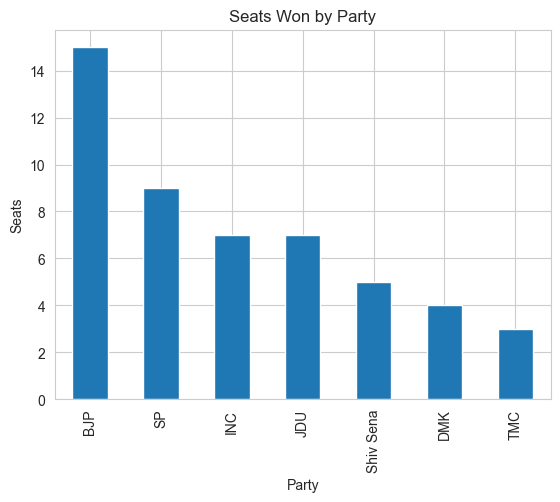

In [36]:
seats_per_party.plot(kind='bar', title='Seats Won by Party', ylabel='Seats', xlabel='Party', colormap='tab20')

TypeError: 'str' object is not callable

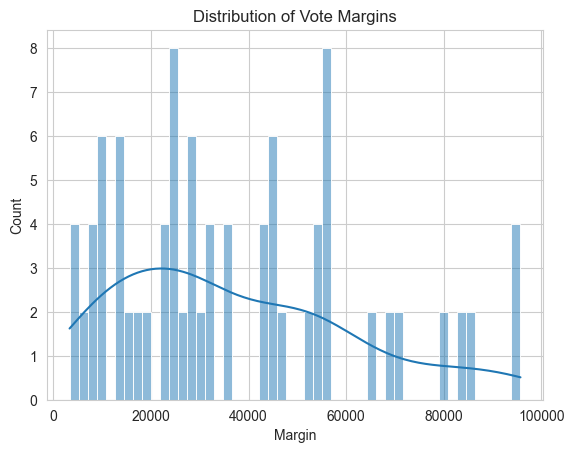

In [39]:
sns.histplot(result['Margin'], bins=50, kde=True)

plt.title('Distribution of Vote Margins')
plt.xlabel('Margin')
plt.ylabel('Frequency')
plt.show()

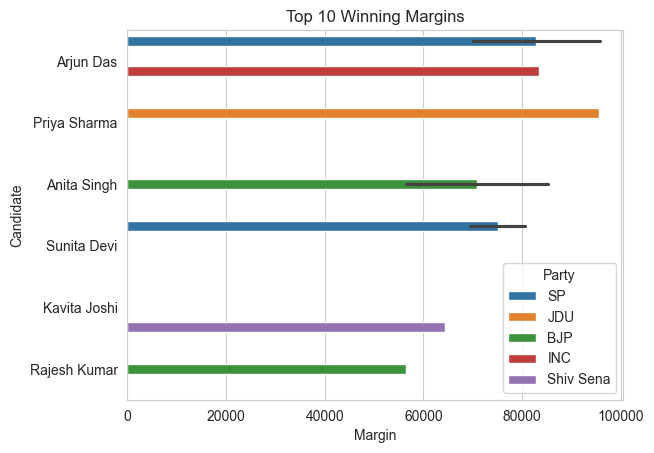

In [40]:
sns.barplot(data=top_margins, x='Margin', y='Candidate', hue='Party')
plt.title('Top 10 Winning Margins')
plt.show()